# 广告转化率预测 —  EDA 与优化分析

本 Notebook 包含:
- 用户行为特征分析
- 多维度交叉分析
- 类别不平衡诊断
- 特征相关性热力图
- 时间模式探索

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

from src.data import load_and_prepare_data

In [2]:
# 加载数据
result = load_and_prepare_data(use_test=False)
df = result['train_val']

print(f'Data shape: {df.shape}')
df.head()

  Duplicated rows: 57423
row after dedup: 3692105   (57423 removed)
  Drop conversionTime column
(3692105, 22)
  Before optimization: 676.04 MB
  After optimization: 186.62 MB
Data shape: (3692105, 24)


,label,clickTime,creativeID,userID,positionID,connectionType,telecomsOperator,adID,advertiserID,appID,...,education,marriageStatus,haveBaby,hometown,residence,appCategory,sitesetID,positionType,user_action_count_before,user_unique_apps_before
0,0,170000,3089,2798058,293,1,1,1321,10,434,...,1,3,1,0,1301,108,0,3,0.0,0.0
1,0,170000,1259,463234,6161,1,2,1535,80,14,...,1,1,0,0,213,2,0,1,0.0,0.0
2,0,170000,4465,1857485,7434,4,1,147,3,465,...,1,0,0,0,1502,209,0,1,0.0,0.0
3,0,170000,1004,2038823,977,1,1,411,3,465,...,0,0,0,0,1001,209,0,1,3.0,3.0
4,0,170000,1887,2015141,3688,1,1,369,84,360,...,2,2,0,1001,1001,201,0,1,0.0,0.0


## 1. 类别不平衡分析

Overall CVR: 0.0253 (2.53%)
Positive ratio: 1:39


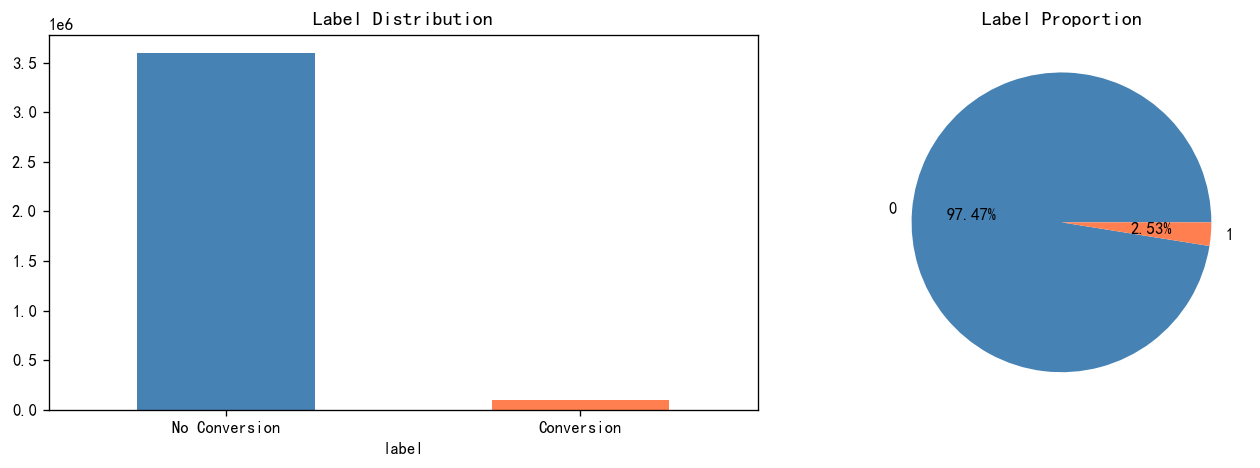

In [3]:
cvr = df['label'].mean()
print(f'Overall CVR: {cvr:.4f} ({cvr*100:.2f}%)')
print(f'Positive ratio: 1:{1/cvr - 1:.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Label Distribution')
axes[0].set_xticklabels(['No Conversion', 'Conversion'], rotation=0)

df['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.2f%%',
                                 colors=['steelblue', 'coral'])
axes[1].set_title('Label Proportion')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 2. 用户行为特征分析

从 user_app_actions 提取的特征分布

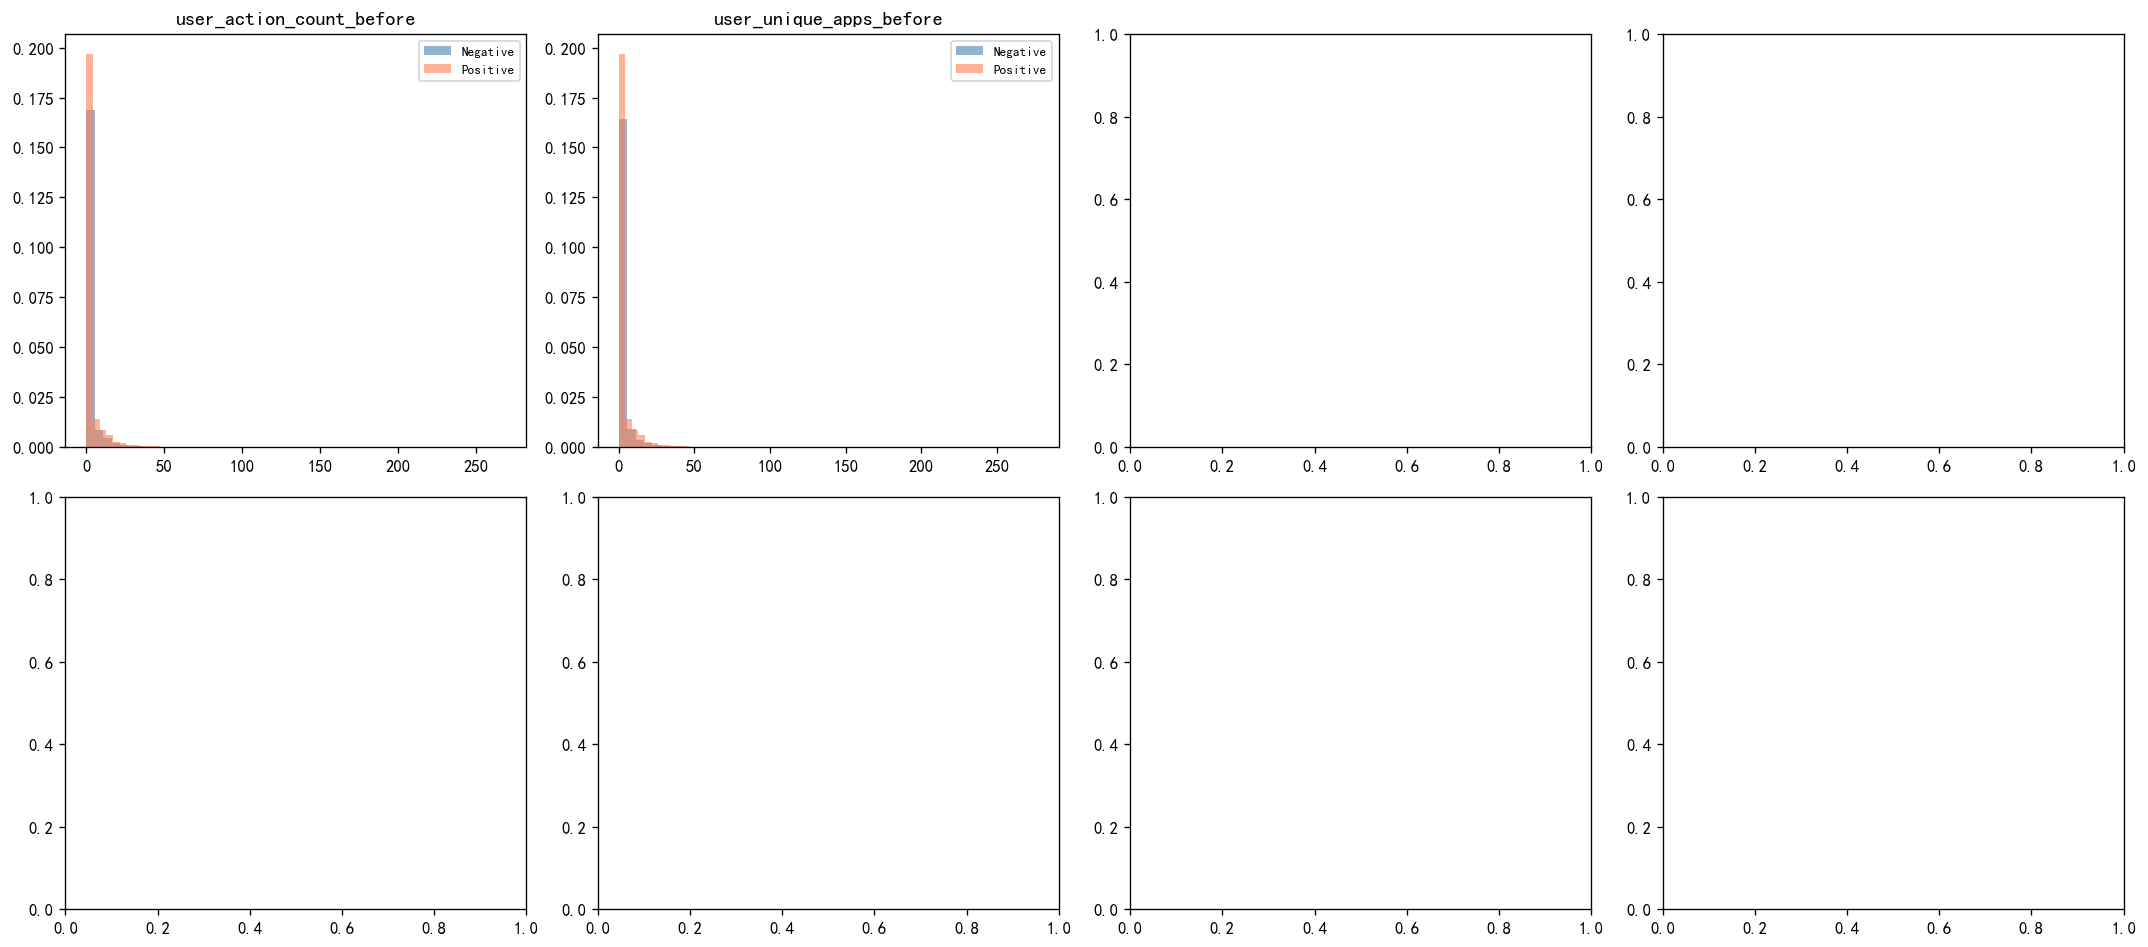

In [4]:
behavior_cols = [c for c in df.columns if c.startswith('user_')]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(behavior_cols[:8]):
    if col in df.columns:
        # Split by label for comparison
        pos = df[df['label']==1][col]
        neg = df[df['label']==0][col].sample(min(50000, (df['label']==0).sum()))
        axes[i].hist(neg, bins=50, alpha=0.6, label='Negative', density=True, color='steelblue')
        axes[i].hist(pos, bins=50, alpha=0.6, label='Positive', density=True, color='coral')
        axes[i].set_title(col)
        axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

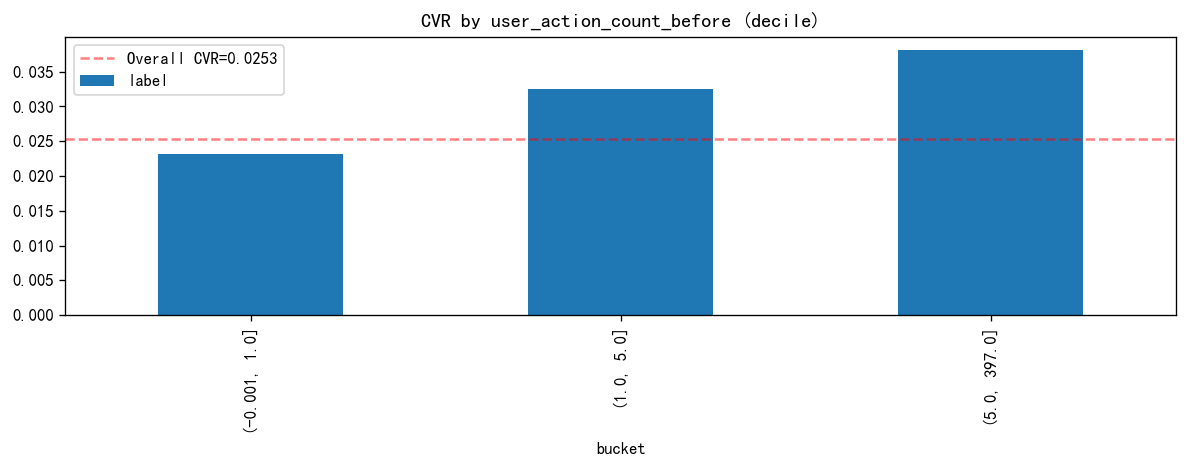

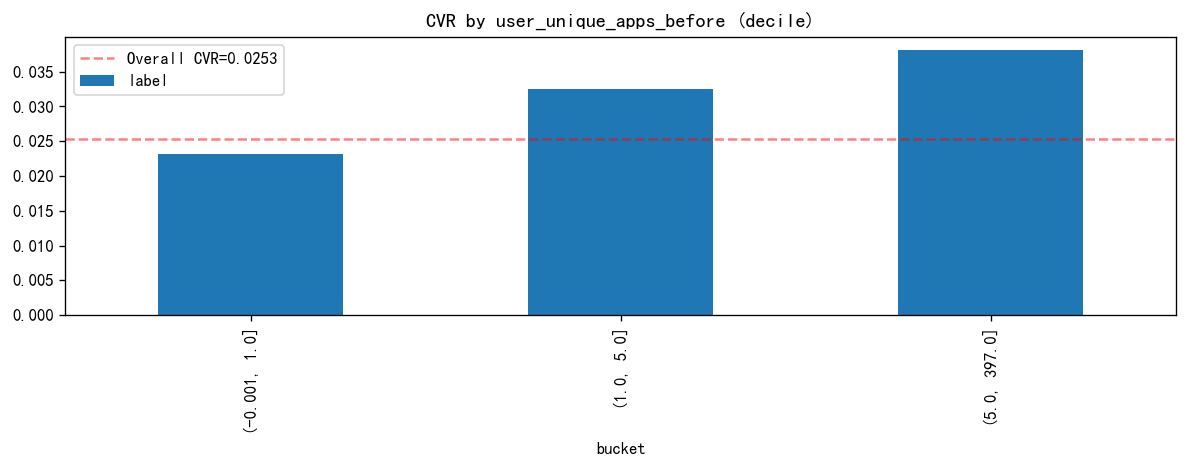

In [5]:
# 行为特征与转化率的关系
for col in behavior_cols:
    if col in df.columns and df[col].nunique() > 2:
        # Bucket and compute CVR
        df_temp = df.copy()
        df_temp['bucket'] = pd.qcut(df_temp[col], q=10, duplicates='drop')
        cvr_by_bucket = df_temp.groupby('bucket', observed=False)['label'].mean()
        cvr_by_bucket.plot(kind='bar', figsize=(10, 4), title=f'CVR by {col} (decile)')
        plt.axhline(y=cvr, color='red', linestyle='--', alpha=0.5, label=f'Overall CVR={cvr:.4f}')
        plt.legend()
        plt.tight_layout()
        plt.show()

## 3. 时间模式深度分析

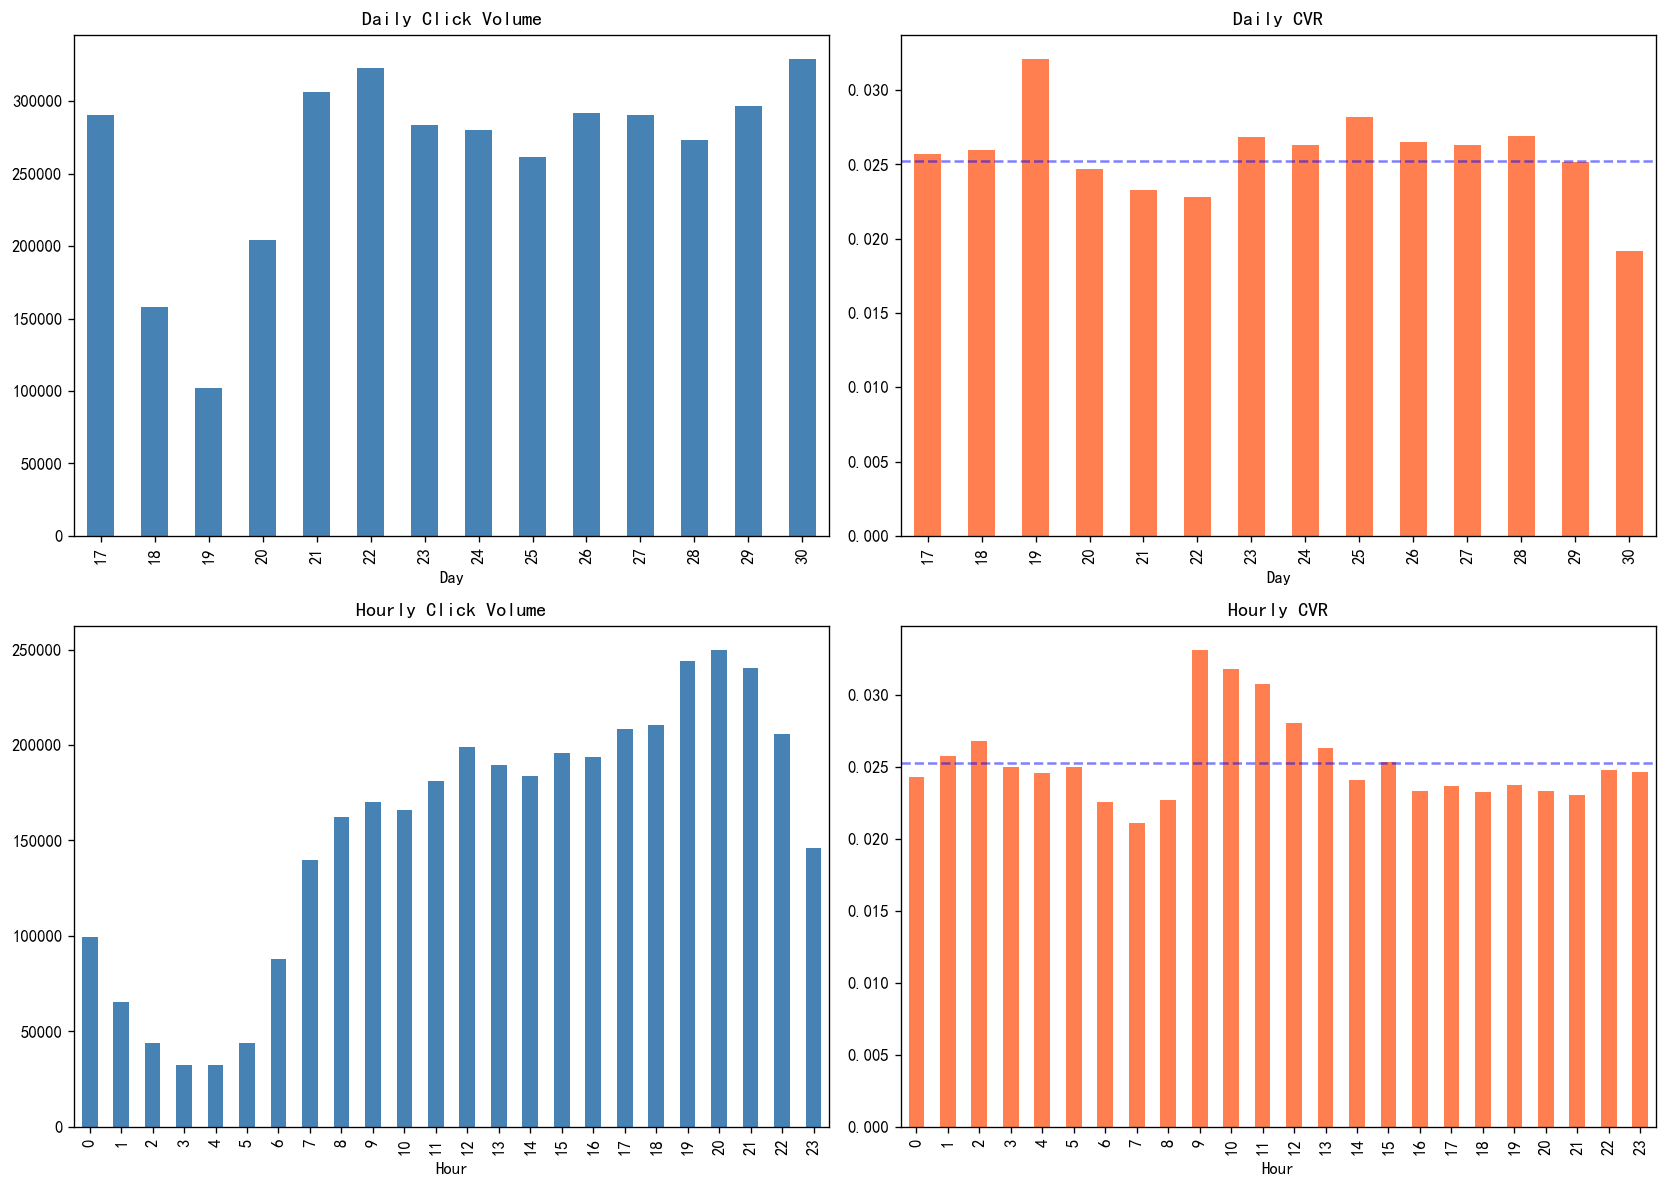

In [6]:
# 提取时间特征
click_time_str = df['clickTime'].astype(str).str.zfill(6)
df['day'] = click_time_str.str[0:2].astype(int)
df['hour'] = click_time_str.str[2:4].astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily click volume
df.groupby('day').size().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Daily Click Volume')
axes[0, 0].set_xlabel('Day')

# Daily CVR
df.groupby('day')['label'].mean().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Daily CVR')
axes[0, 1].set_xlabel('Day')
axes[0, 1].axhline(y=cvr, color='blue', linestyle='--', alpha=0.5)

# Hourly click volume
df.groupby('hour').size().plot(kind='bar', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Hourly Click Volume')
axes[1, 0].set_xlabel('Hour')

# Hourly CVR
df.groupby('hour')['label'].mean().plot(kind='bar', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Hourly CVR')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].axhline(y=cvr, color='blue', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 4. 多维度交叉 CVR 热力图

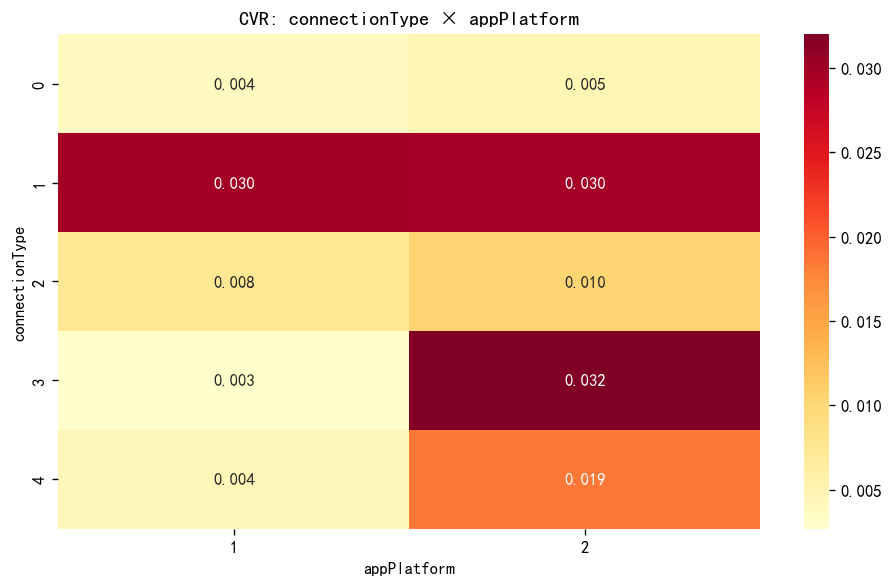

In [7]:
# 提取 first_category（appCategory 已在数据加载时 merge 进来）
cate_str = df['appCategory'].astype(str).str.zfill(2)
df['first_cat'] = cate_str.str[0].astype(int)

# connectionType x appPlatform CVR heatmap
if 'connectionType' in df.columns and 'appPlatform' in df.columns:
    cross_cvr = df.pivot_table(values='label', index='connectionType',
                                columns='appPlatform', aggfunc='mean')
    plt.figure(figsize=(8, 5))
    sns.heatmap(cross_cvr, annot=True, fmt='.3f', cmap='YlOrRd')
    plt.title('CVR: connectionType × appPlatform')
    plt.tight_layout()
    plt.show()

Top 15 features by correlation with label:
sitesetID                   0.076664
positionType                0.059149
first_cat                   0.045369
appCategory                 0.044230
connectionType              0.042951
advertiserID                0.039629
positionID                  0.024544
user_unique_apps_before     0.024125
user_action_count_before    0.024125
creativeID                  0.018210
education                   0.013635
adID                        0.013282
telecomsOperator            0.011729
hometown                    0.011121
gender                      0.005910
dtype: float64


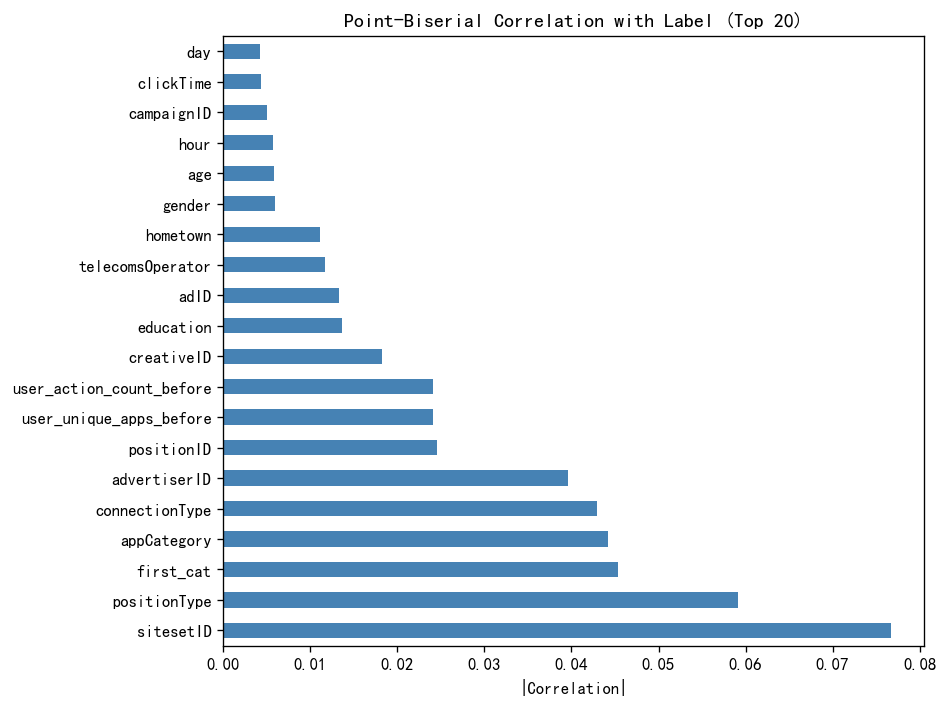

In [8]:
# 各特征与 label 的点二列相关系数 (用于快速筛选有用特征)
from scipy.stats import pointbiserialr

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = {}
for col in numeric_cols:
    if col != 'label' and df[col].nunique() > 1:
        try:
            corr, pval = pointbiserialr(df[col].fillna(0), df['label'])
            correlations[col] = abs(corr)
        except:
            pass

corr_df = pd.Series(correlations).sort_values(ascending=False)
print('Top 15 features by correlation with label:')
print(corr_df.head(15))

corr_df.head(20).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Point-Biserial Correlation with Label (Top 20)')
plt.xlabel('|Correlation|')
plt.tight_layout()
plt.show()

## 5. 高基数特征分析

分析 userID、creativeID 等高基数特征的转化率分布

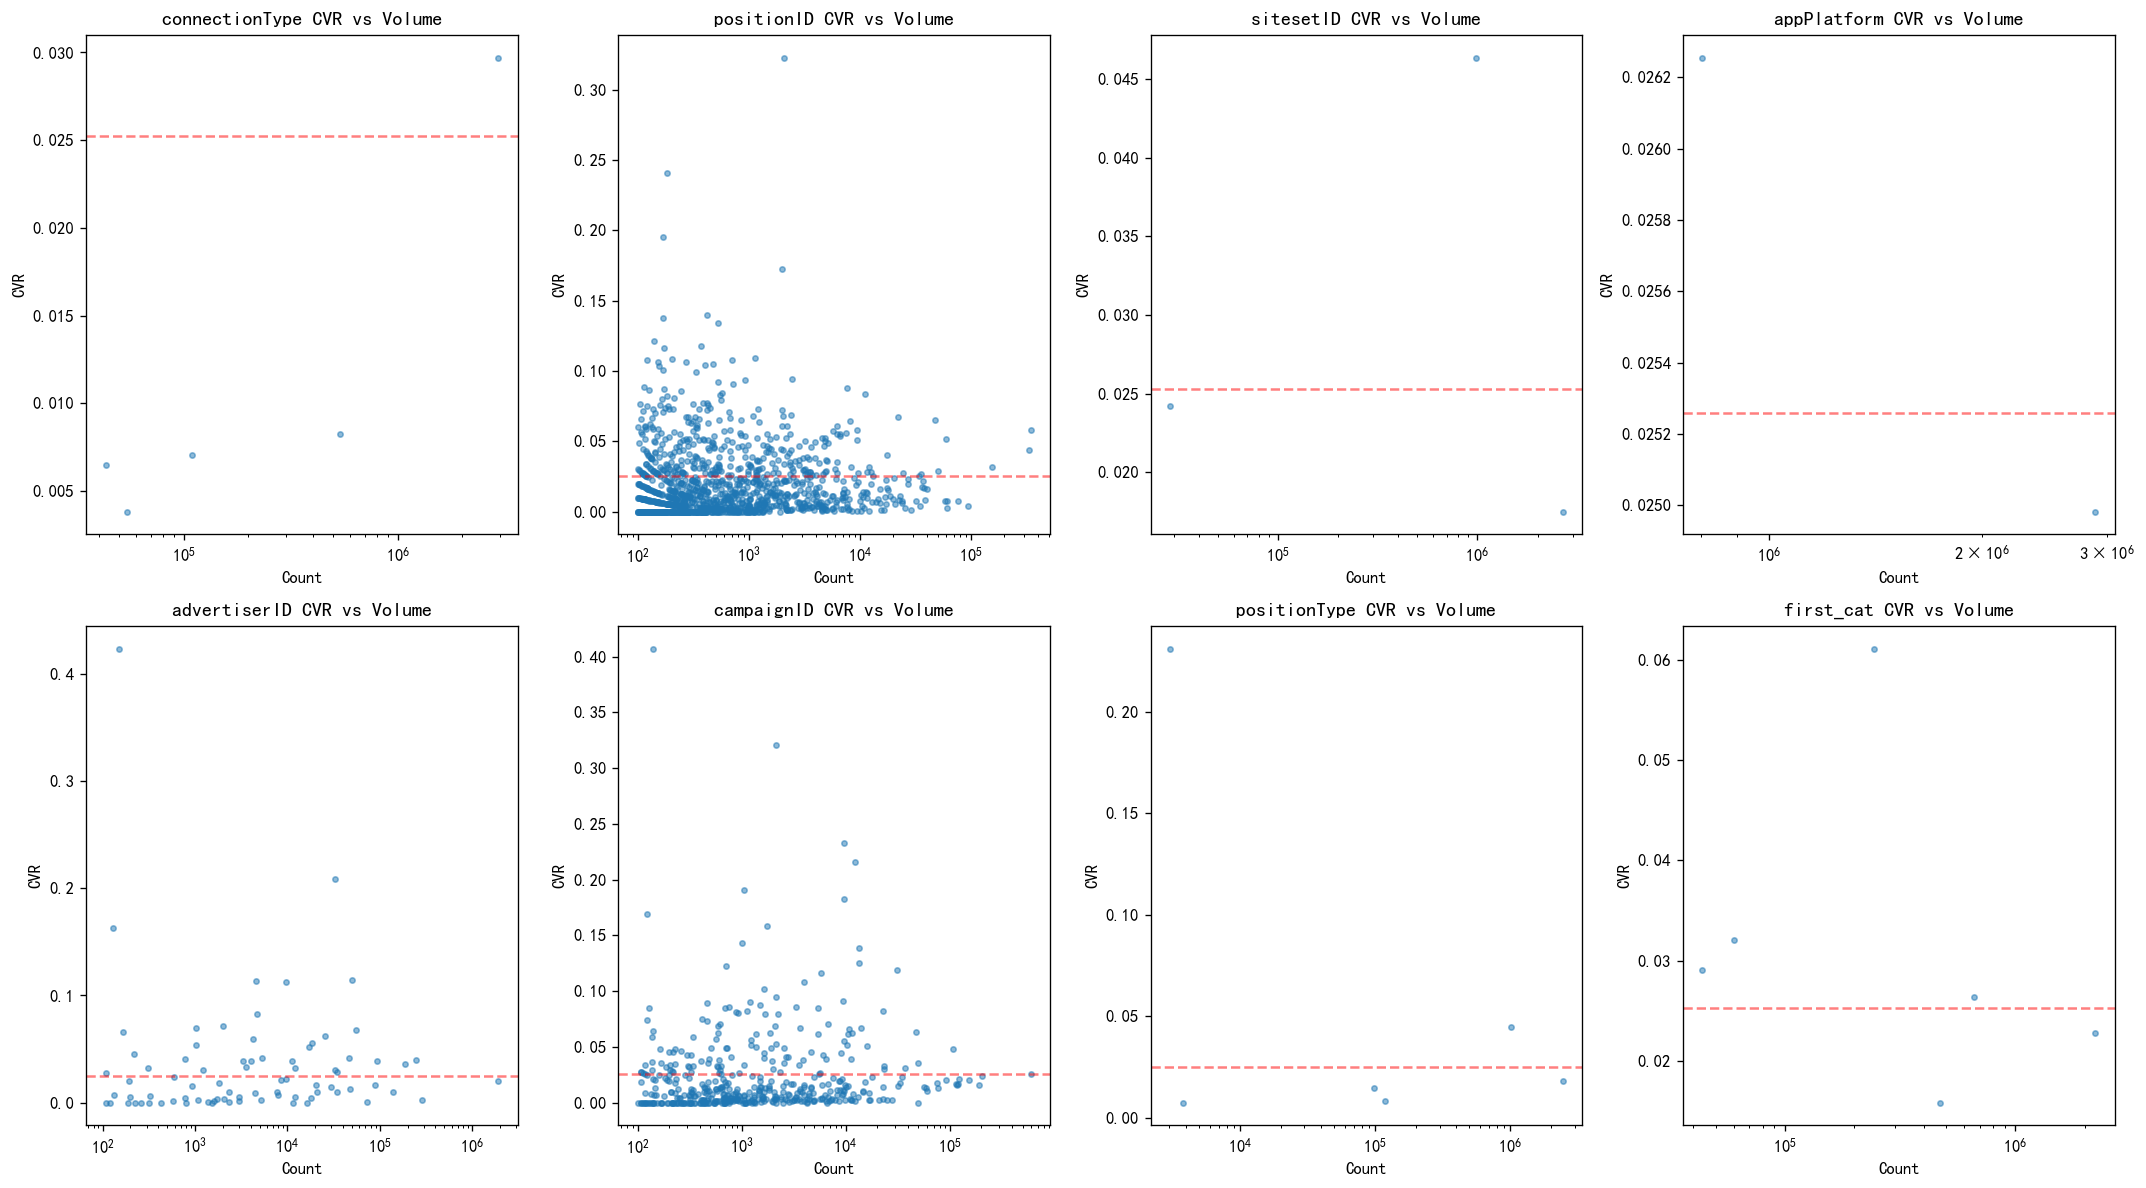

In [9]:
high_card_cols = ['connectionType', 'positionID', 'sitesetID', 'appPlatform',
                  'advertiserID', 'campaignID', 'positionType', 'first_cat']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(high_card_cols):
    if col in df.columns:
        stats = df.groupby(col).agg(
            cvr=('label', 'mean'),
            count=('label', 'count')
        ).query('count >= 100')
        
        axes[i].scatter(stats['count'], stats['cvr'], alpha=0.5, s=10)
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel('CVR')
        axes[i].set_title(f'{col} CVR vs Volume')
        axes[i].axhline(y=cvr, color='red', linestyle='--', alpha=0.5)
        axes[i].set_xscale('log')

plt.tight_layout()
plt.show()